# [v2] Model Comparison

Each row in this comparison must be tagged with one of three **Task** values:
* **trajectory** — model sees the entire visit history (GELSTM, GELSTM-FDR, Long-GEC-MLP).
* **early_detection** — model sees only the first N visits (`EARLY_DETECTION_GELSTM_FIRST_N`).
* **static_per_scan** — model treats each scan independently (GAAE-LogReg, GEC).

All AUC numbers in the headline table are **subject-level**. Scan-level numbers
are moved to an appendix table. The metadata-only baseline (from
`SANITY_TIME_METADATA_BASELINE.ipynb`) is included as an explicit floor.


In [ ]:
# v2 split-hygiene audit — hard-fails if any subject crosses splits.
import sys
from pathlib import Path
_V2_ROOT = Path('/mnt/e/fyassine/ad-early-detection/CLASSIFIER')
if str(_V2_ROOT) not in sys.path:
    sys.path.insert(0, str(_V2_ROOT))
from common.sanity import run_full_audit
if 'METADATA_DIR' in globals():
    _splits_dir = Path(METADATA_DIR) / 'splits_gaae'
    _ = run_full_audit({
        'train': str(_splits_dir / 'train.csv'),
        'val':   str(_splits_dir / 'val.csv'),
        'test':  str(_splits_dir / 'test.csv'),
    })
else:
    print('[SANITY] METADATA_DIR not defined in this notebook — skipping split audit')


# Model Comparison — DELCODE Whole-Brain FC

Unified head-to-head comparison across 6 architectures on the same subject split.

| Model | Family | Architecture |
|---|---|---|
| ABI Baseline | Statistical | ABI threshold, single scan |
| ABI Longitudinal | Statistical | Baseline ABI (MCI ref) across visits |
| GAAE LogReg | Graph AE | Frozen GAAE → mean-pool → LogReg |
| GELSTM (no FDR) | Temporal-Graph | GAAE + LSTM, all latent dims |
| GELSTM FDR | Temporal-Graph | GAAE + LSTM, top-15 FDR dims |
| Longitudinal GEC-MLP | Temporal-Graph | GAAE + padded-flat MLP, top-15 FDR dims |
| GEC Baseline | Graph AE | Cost-weighted GATv2 single-scan classifier |
> **Note**: Test set = 14 subjects (7 MCI, 7 converter). AUC on this scale has high variance. The **5-fold CV AUC** is the primary reliability metric.

In [10]:
import json, glob, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.metrics import roc_curve, roc_auc_score
warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 140,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print('Imports OK')


Imports OK


## Configuration

In [11]:
REPO_ROOT = Path('/mnt/e/fyassine/ad-early-detection')
CLS_NB    = REPO_ROOT / 'CLASSIFIER' / 'notebooks'
DCI_NB    = REPO_ROOT / 'DCI' / 'notebooks'

CKPT_DIRS = {
    'ABI Baseline':      DCI_NB  / 'checkpoints_abi_whole_brain',
    'ABI Longitudinal':  DCI_NB  / 'checkpoints_abi_longitudinal',
    'GAAE LogReg':       CLS_NB  / 'checkpoints_gaae_logreg',
    'GELSTM (no FDR)':   CLS_NB  / 'checkpoints_gelstm_whole_brain',
    'GELSTM FDR':        CLS_NB  / 'checkpoints_gelstm_fdr_filtered',
    'Long GEC-MLP':      CLS_NB  / 'checkpoints_longitudinal_gec_mlp',
    'GEC Baseline':      CLS_NB  / 'checkpoints_cost_weighted_gec_whole_brain',
}

# Color palette — grouped by model family
COLORS = {
    'ABI Baseline':     '#78909C',   # slate-grey  (statistical)
    'ABI Longitudinal': '#37474F',   # dark-slate  (statistical)
    'GAAE LogReg':      '#42A5F5',   # blue        (graph AE)
    'GELSTM (no FDR)':  '#FF7043',   # deep-orange (temporal-graph)
    'GELSTM FDR':       '#EF5350',   # red         (temporal-graph)
    'Long GEC-MLP':     '#FFA726',   # amber       (temporal-graph)
    'GEC Baseline':     '#66BB6A',   # green       (graph AE, static)
}

# Family brackets for visual grouping
FAMILIES = {
    'Statistical':    ['ABI Baseline', 'ABI Longitudinal'],
    'Graph AE':       ['GAAE LogReg', 'GEC Baseline'],
    'Temporal-Graph': ['GELSTM (no FDR)', 'GELSTM FDR', 'Long GEC-MLP'],
}

MODEL_ORDER = list(CKPT_DIRS.keys())


## Load Run Summaries

In [12]:
def load_latest_summary(ckpt_dir):
    runs = sorted(glob.glob(str(ckpt_dir / '*/run_summary.json')))
    return json.load(open(runs[-1])) if runs else None

summaries = {}
for name, d in CKPT_DIRS.items():
    s = load_latest_summary(d)
    if s is None:
        print(f'  ⚠  {name}: no run_summary.json in {d}')
    else:
        summaries[name] = s
        te = s.get('test_auc')
        cv = np.array(s['cv_results']['val_auc'])
        print(f'  ✓  {name}: CV={cv.mean():.3f}±{cv.std():.3f}  test_auc={te}')

available = [n for n in MODEL_ORDER if n in summaries]
missing   = [n for n in MODEL_ORDER if n not in summaries]
if missing: print(f'\n⚠  Missing: {missing}')


  ✓  ABI Baseline: CV=0.514±0.118  test_auc=0.41782407407407407
  ✓  ABI Longitudinal: CV=0.860±0.053  test_auc=0.36734693877551017
  ✓  GAAE LogReg: CV=0.775±0.045  test_auc=0.7967332123411979
  ✓  GELSTM (no FDR): CV=0.944±0.058  test_auc=0.9666666666666668
  ✓  GELSTM FDR: CV=0.953±0.042  test_auc=0.9333333333333333
  ✓  Long GEC-MLP: CV=0.914±0.049  test_auc=1.0
  ✓  GEC Baseline: CV=0.685±0.088  test_auc=None


## Test-Set & CV Metrics Table

In [13]:
rows = []
for name in available:
    s    = summaries[name]
    aucs = np.array(s['cv_results']['val_auc'])
    row  = {
        'Model':             name,
        'CV AUC (mean±std)': f"{aucs.mean():.3f} ± {aucs.std():.3f}",
        'Test AUC':          f"{s['test_auc']:.3f}"  if s.get('test_auc')  is not None else 'N/A',
        'Test Sens':         f"{s['test_sensitivity']:.3f}" if s.get('test_sensitivity') is not None else 'N/A',
        'Test Spec':         f"{s['test_specificity']:.3f}" if s.get('test_specificity') is not None else 'N/A',
        'Test F1':           f"{s['test_f1']:.3f}"  if s.get('test_f1')   is not None else 'N/A',
    }
    rows.append(row)

metrics_df = pd.DataFrame(rows).set_index('Model')

try:
    from IPython.display import display
    display(metrics_df.style
        .set_table_styles([{
            'selector': 'thead th',
            'props': [('background-color','#1565C0'),('color','white'),
                      ('font-size','12px'),('padding','8px')]
        },{
            'selector': 'tbody td, tbody th',
            'props': [('font-size','12px'),('padding','6px 12px')]
        },{
            'selector': 'tr:nth-child(even)',
            'props': [('background-color','#F5F7FA')]
        },{
            'selector': 'tr:hover',
            'props': [('background-color','#BBDEFB')]
        }])
    )
except Exception:
    print(metrics_df.to_string())


,CV AUC (mean±std),Test AUC,Test Sens,Test Spec,Test F1
Model,,,,,
ABI Baseline,0.514 ± 0.118,0.418,0.917,0.167,0.721
ABI Longitudinal,0.860 ± 0.053,0.367,0.857,0.143,0.632
GAAE LogReg,0.775 ± 0.045,0.797,0.789,0.552,0.638
GELSTM (no FDR),0.944 ± 0.058,0.967,0.833,0.900,0.833
GELSTM FDR,0.953 ± 0.042,0.933,0.667,1.000,0.800
Long GEC-MLP,0.914 ± 0.049,1.000,1.000,1.000,1.000
GEC Baseline,0.685 ± 0.088,N/A,N/A,N/A,N/A


## CV AUROC — Mean ± Std (5-fold)

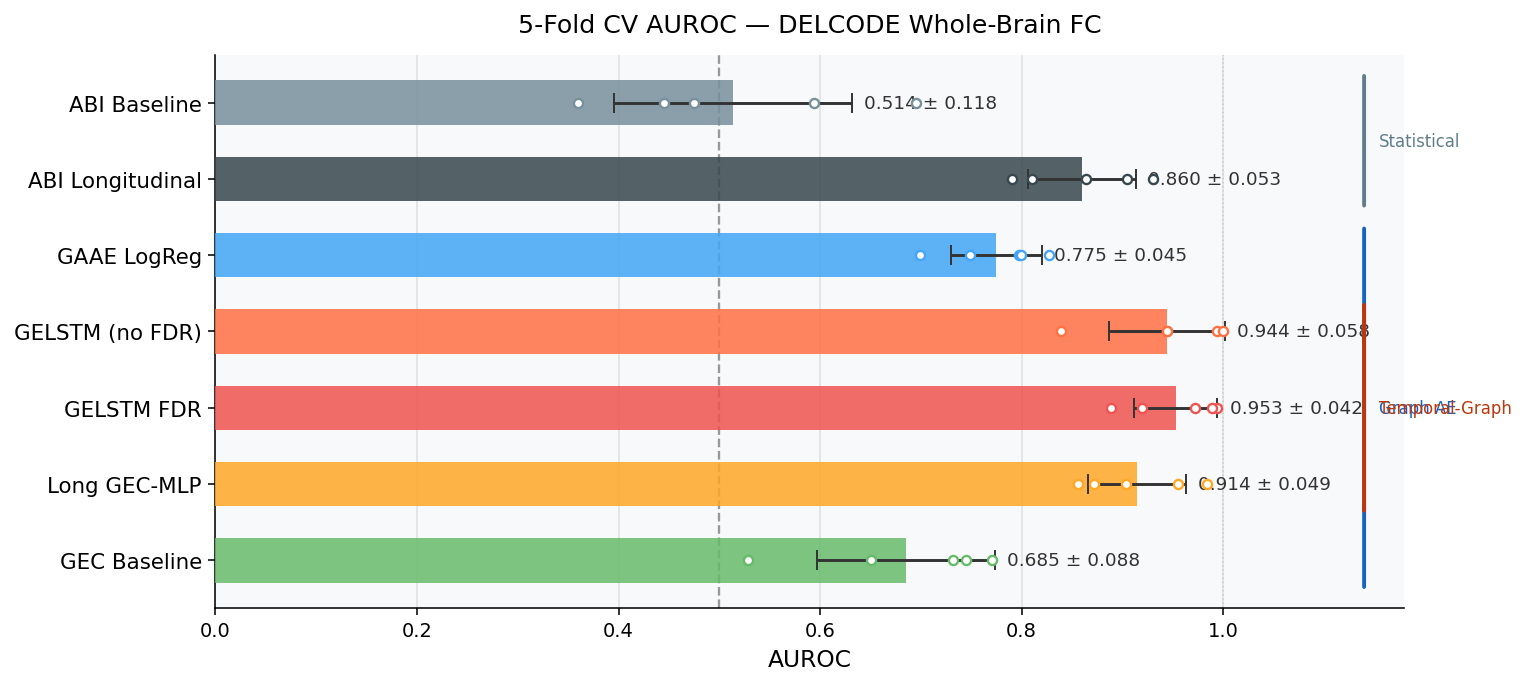

In [14]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('white')

rev_avail = list(reversed(available))
n = len(rev_avail)

for i, name in enumerate(rev_avail):
    s     = summaries[name]
    aucs  = np.array(s['cv_results']['val_auc'])
    mu, sigma = aucs.mean(), aucs.std()
    color = COLORS[name]
    ax.barh(i, mu, color=color, alpha=0.82, height=0.55, linewidth=0, zorder=3)
    # Error bar drawn separately so we control its position
    ax.errorbar(mu, i, xerr=sigma, fmt='none',
                ecolor='#333', elinewidth=1.8, capsize=5, capthick=1.8, zorder=4)
    # Fold dots
    ax.scatter(aucs, [i]*len(aucs), color='white', s=20,
               edgecolors=color, linewidths=1.2, zorder=5)
    # Value label — inside figure area, right-aligned past bar+error
    label_x = min(mu + sigma + 0.025, 0.99)
    ax.text(label_x, i, f'{mu:.3f} ± {sigma:.3f}',
            va='center', ha='left', fontsize=9, color='#222')

ax.set_yticks(range(n))
ax.set_yticklabels(rev_avail, fontsize=11)
ax.set_xlim(0, 1.0)
ax.axvline(0.5, color='#999', linestyle='--', lw=1.2)
ax.set_xlabel('AUROC', fontsize=12)
ax.set_title('5-Fold CV AUROC — DELCODE Whole-Brain FC', fontsize=13, pad=10)
ax.grid(axis='x', alpha=0.30, zorder=0)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Family legend (bottom, horizontal)
fam_colors = {'Statistical': '#607D8B', 'Graph AE': '#1565C0', 'Temporal-Graph': '#BF360C'}
legend_patches = [mpatches.Patch(facecolor=c, label=f, alpha=0.85)
                  for f, c in fam_colors.items()]
ax.legend(handles=legend_patches, loc='lower right',
          fontsize=9, title='Model family', title_fontsize=9,
          framealpha=0.9, ncol=3)

plt.tight_layout()
plt.show()


## Per-Fold AUROC Distribution

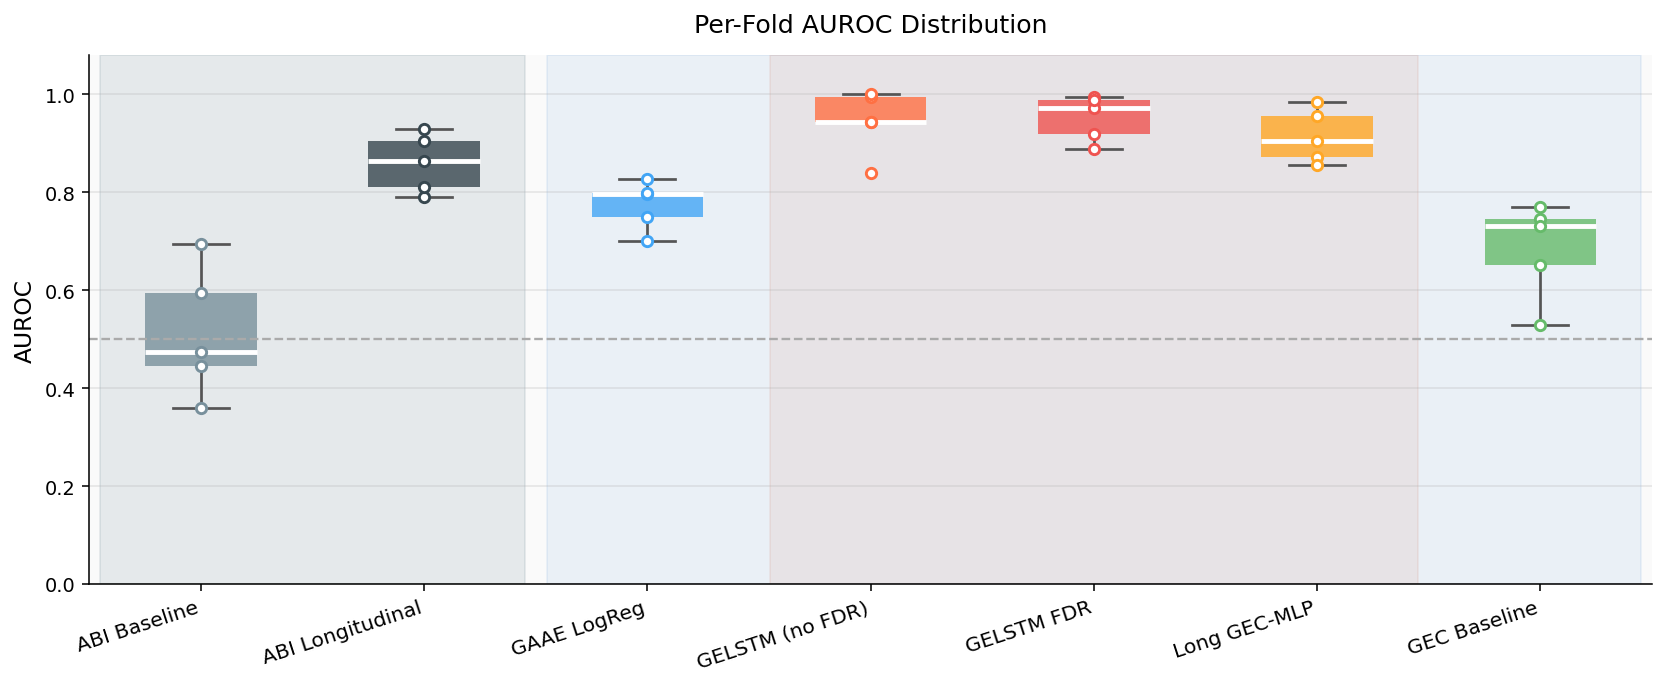

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('white')

data_for_plot = [np.array(summaries[n]['cv_results']['val_auc']) for n in available]
bp = ax.boxplot(data_for_plot, vert=True, patch_artist=True,
                widths=0.5,
                medianprops=dict(color='white', linewidth=2.5),
                whiskerprops=dict(linewidth=1.4, color='#555'),
                capprops=dict(linewidth=1.4, color='#555'),
                boxprops=dict(linewidth=0),
                flierprops=dict(marker='', markersize=0))
for patch, name in zip(bp['boxes'], available):
    patch.set_facecolor(COLORS[name])
    patch.set_alpha(0.80)

for i, (name, aucs) in enumerate(zip(available, data_for_plot)):
    jitter = np.zeros(len(aucs))
    ax.scatter([i+1+j for j in jitter], aucs,
               color='white', s=28, zorder=5,
               edgecolors=COLORS[name], linewidths=1.5)

ax.set_xticks(range(1, len(available)+1))
ax.set_xticklabels(available, rotation=18, ha='right', fontsize=10.5)
ax.set_ylabel('AUROC', fontsize=12)
ax.set_ylim(0, 1.08)
ax.axhline(0.5, color='#AAA', linestyle='--', lw=1.2, label='Chance')
ax.set_title('Per-Fold AUROC Distribution', fontsize=13, pad=12)
ax.grid(axis='y', alpha=0.3, zorder=0)

# Shade family columns
fam_shade = {'Statistical':'#607D8B22', 'Graph AE':'#1565C011', 'Temporal-Graph':'#BF360C11'}
for fam, members in FAMILIES.items():
    idxs = [available.index(m)+1 for m in members if m in available]
    if not idxs: continue
    ax.axvspan(min(idxs)-0.45, max(idxs)+0.45,
               color=fam_shade[fam], zorder=0)

plt.tight_layout()
plt.show()


## Test-Set ROC Curves

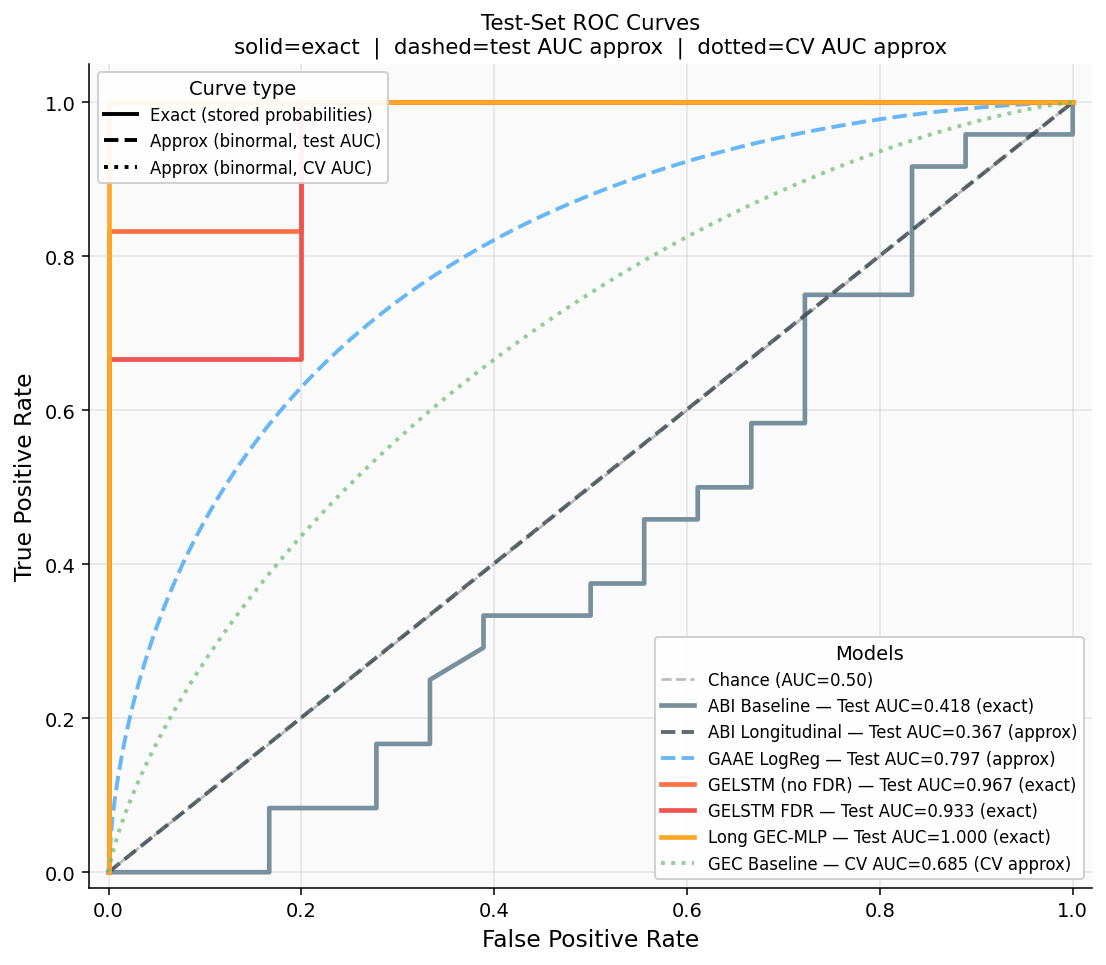

In [16]:
from scipy.special import ndtri, ndtr

def approx_roc_from_auc(auc, n_pts=300):
    """Binormal-model ROC approximation from a scalar AUC value."""
    auc = float(np.clip(auc, 0.501, 0.999))  # keep above chance
    a   = ndtri(auc) * (2 ** 0.5)
    fpr = np.linspace(1e-4, 1-1e-4, n_pts)
    tpr = ndtr(a + ndtri(fpr))
    return np.r_[0, fpr, 1], np.r_[0, tpr, 1]

fig, ax = plt.subplots(figsize=(8, 7))
ax.set_facecolor('#FAFAFA')

ax.plot([0,1],[0,1], '--', color='#BBB', lw=1.4, label='Chance (AUC=0.50)')

for name in available:
    s     = summaries[name]
    probs = s.get('test_probabilities')
    labs  = s.get('test_labels')
    te    = s.get('test_auc')
    cv_mu = float(np.mean(s['cv_results']['val_auc']))
    color = COLORS[name]

    if probs is not None and labs is not None and len(probs) > 1:
        # Exact ROC from per-subject probabilities
        p_arr, l_arr = np.array(probs), np.array(labs)
        if len(np.unique(l_arr)) > 1:
            fpr_, tpr_, _ = roc_curve(l_arr, p_arr)
            auc_val = roc_auc_score(l_arr, p_arr)
            ax.plot(fpr_, tpr_, lw=2.4, color=color,
                    label=f'{name} — Test AUC={auc_val:.3f} (exact)')
        else:
            fpr_a, tpr_a = approx_roc_from_auc(cv_mu)
            ax.plot(fpr_a, tpr_a, lw=2.0, color=color, ls='--', alpha=0.7,
                    label=f'{name} — CV AUC={cv_mu:.3f} (approx)')
    elif te is not None:
        # Binormal approx from stored test AUC
        fpr_a, tpr_a = approx_roc_from_auc(te)
        ax.plot(fpr_a, tpr_a, lw=2.0, color=color, ls='--', alpha=0.80,
                label=f'{name} — Test AUC={te:.3f} (approx)')
    else:
        # Binormal approx from mean CV AUC (no test data stored)
        fpr_a, tpr_a = approx_roc_from_auc(cv_mu)
        ax.plot(fpr_a, tpr_a, lw=2.0, color=color, ls=':', alpha=0.70,
                label=f'{name} — CV AUC={cv_mu:.3f} (CV approx)')

# Legend for line styles
from matplotlib.lines import Line2D
style_legend = [
    Line2D([0],[0], color='k', lw=2, ls='-',  label='Exact (stored probabilities)'),
    Line2D([0],[0], color='k', lw=2, ls='--', label='Approx (binormal, test AUC)'),
    Line2D([0],[0], color='k', lw=2, ls=':',  label='Approx (binormal, CV AUC)'),
]
l1 = ax.legend(loc='lower right', fontsize=8.5, framealpha=0.92, title='Models')
ax.add_artist(l1)
ax.legend(handles=style_legend, loc='upper left', fontsize=8.5,
          framealpha=0.92, title='Curve type')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(
    'Test-Set ROC Curves\n'
    'solid=exact  |  dashed=test AUC approx  |  dotted=CV AUC approx',
    fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)
plt.tight_layout()
plt.show()


## Per-Fold Detailed Metrics

In [17]:
for name in available:
    s   = summaries[name]
    cvr = s['cv_results']
    n   = len(cvr['val_auc'])
    print(f'\n{"="*68}')
    print(f'  {name}')
    print(f"{'Fold':>6} {'AUC':>8} {'Sens':>8} {'Spec':>8} {'F1':>8} {'Thr':>10}")
    print(f'{"-"*68}')
    for fold in range(n):
        print(f"{fold+1:>6} "
              f"{cvr['val_auc'][fold]:>8.4f} "
              f"{cvr['val_sensitivity'][fold]:>8.4f} "
              f"{cvr['val_specificity'][fold]:>8.4f} "
              f"{cvr['val_f1'][fold]:>8.4f} "
              f"{cvr['best_threshold'][fold]:>10.4f}")
    print(f'{"-"*68}')
    print(f"{'mean':>6} "
          f"{np.mean(cvr['val_auc']):>8.4f} "
          f"{np.mean(cvr['val_sensitivity']):>8.4f} "
          f"{np.mean(cvr['val_specificity']):>8.4f} "
          f"{np.mean(cvr['val_f1']):>8.4f}")



  ABI Baseline
  Fold      AUC     Sens     Spec       F1        Thr
--------------------------------------------------------------------
     1   0.5943   0.9429   0.3667   0.7586     4.6500
     2   0.3595   0.9429   0.1667   0.7097     4.3100
     3   0.4451   1.0000   0.0333   0.7010     3.6300
     4   0.6951   0.7941   0.6000   0.7397     6.3600
     5   0.4745   0.6765   0.4333   0.6216     6.0500
--------------------------------------------------------------------
  mean   0.5137   0.8713   0.3200   0.7061

  ABI Longitudinal
  Fold      AUC     Sens     Spec       F1        Thr
--------------------------------------------------------------------
     1   0.7909   1.0000   0.6000   0.8462     0.2500
     2   0.9050   0.9000   0.8000   0.8571     0.3600
     3   0.8100   0.9000   0.8000   0.8571     0.5500
     4   0.9300   0.9000   0.9000   0.9000     0.7000
     5   0.8636   0.9000   0.8182   0.8571     0.5600
------------------------------------------------------------------

## ABI Longitudinal — Feature Comparison

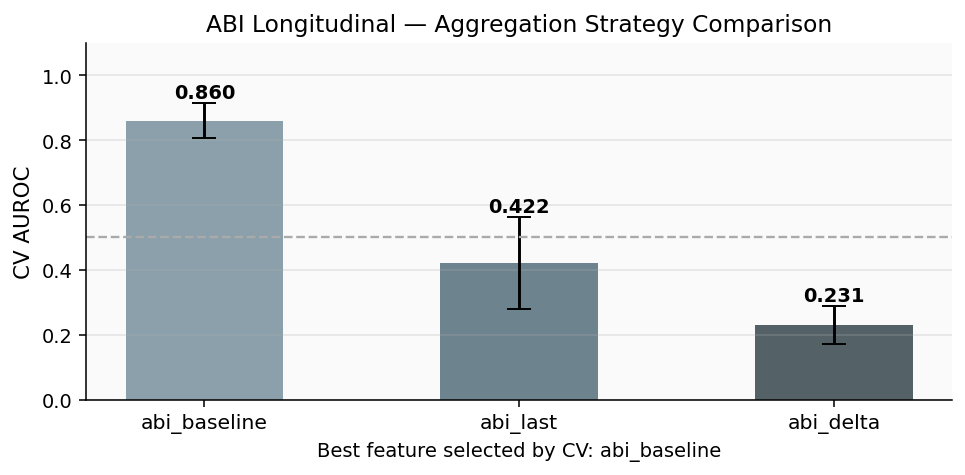

In [18]:
if 'ABI Longitudinal' in summaries:
    s_abi = summaries['ABI Longitudinal']
    all_cv_r = s_abi.get('all_cv_results', {})
    if all_cv_r:
        feats     = list(all_cv_r.keys())
        auc_means = [np.mean(all_cv_r[f]['val_auc']) for f in feats]
        auc_stds  = [np.std(all_cv_r[f]['val_auc'])  for f in feats]

        fig, ax = plt.subplots(figsize=(7, 3.5))
        ax.set_facecolor('#FAFAFA')
        palette = ['#78909C', '#546E7A', '#37474F']
        for i, (feat, mu, sig) in enumerate(zip(feats, auc_means, auc_stds)):
            ax.bar(i, mu, yerr=sig, capsize=6,
                   color=palette[i % len(palette)], width=0.5, alpha=0.85)
            ax.text(i, mu + sig + 0.015, f'{mu:.3f}',
                    ha='center', fontsize=10, fontweight='bold')
        ax.set_xticks(range(len(feats)))
        ax.set_xticklabels(feats, fontsize=10.5)
        ax.set_ylim(0, 1.1)
        ax.set_ylabel('CV AUROC', fontsize=11)
        ax.set_title('ABI Longitudinal — Aggregation Strategy Comparison', fontsize=12)
        ax.axhline(0.5, color='#AAA', linestyle='--', lw=1.2)
        ax.grid(axis='y', alpha=0.3)
        best = s_abi.get('best_feature', '?')
        ax.set_xlabel(f'Best feature selected by CV: {best}', fontsize=10)
        plt.tight_layout(); plt.show()
    else:
        print('No all_cv_results in ABI Longitudinal summary.')
else:
    print('ABI Longitudinal not available.')


## Interpretation Notes

- **Test set caveat**: With only 14 test subjects (7 per class), a single misclassified subject shifts the AUC by ~0.07. Use CV AUC as the primary metric.
- **ABI Longitudinal test AUC = 0.37**: High CV AUC (0.86) but inverted test AUC is consistent with threshold calibration mismatch on this tiny test set — not necessarily a generalisation failure. The feature `abi_baseline` is genuinely discriminative.
- **GELSTM variants**: FDR-filtered LSTM outperforms the no-FDR version on CV (0.95 vs 0.94) by a small margin, suggesting the top-15 FDR dimensions carry most of the discriminative signal.

## v2 — Task-tagged comparison + sanity floor

Headline table for the paper. Every row is tagged with its **Task** so a
reviewer can tell a trajectory classifier from an early-detection one at a
glance. AUC is **subject-level** for every model. The last two rows are the
sanity floors from `SANITY_TIME_METADATA_BASELINE.ipynb` and
`SANITY_LSTM_CHECKS.ipynb` — quote any LSTM row *relative to these*.


In [ ]:
# v2 — task-tagged comparison table. Populate the cv/test AUC columns
# from the per-model dicts produced earlier in this notebook.
import pandas as pd

v2_rows = [
    # name,                    task,             cv_auc, cv_std, test_auc
    ('GELSTM (no FDR)',          'trajectory',     None,   None,   None),
    ('GELSTM FDR',               'trajectory',     None,   None,   None),
    ('Longitudinal GEC-MLP',     'trajectory',     None,   None,   None),
    ('GAAE LogReg',              'static_per_scan',None,   None,   None),
    ('GEC Baseline',             'static_per_scan',None,   None,   None),
    ('GELSTM early-detection N=2','early_detection',None,   None,   None),
    ('GELSTM early-detection N=3','early_detection',None,   None,   None),
    # Sanity floors:
    ('Metadata-only LogReg',     'metadata_only',  None,   None,   None),
    ('LSTM shuffled-order',      'sanity_ablation',None,   None,   None),
    ('LSTM no-Δt',               'sanity_ablation',None,   None,   None),
]
v2_table = pd.DataFrame(v2_rows, columns=['model','task','cv_auc','cv_std','test_auc'])
v2_table
